# Velocity distribution: Double Maxwell-Boltzmann distribution

Our current best estimate for the voxel velocity distribution is the skewnormal distribution. However, physically speaking, a double MB would make sense, being the sum of two zero-centered Gaussians. In this notebook, we test its performance.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import my_functions as mf
from scipy.optimize import minimize
from scipy.stats import skewnorm

In [2]:
dmo_small = mf.load_simulation('L1m9_dmo_fiducial', '0077', '11+', 100)
dmo_large = mf.load_simulation('L2p8m9_dmo_fiducial', '0078', '11+', 280)

In [3]:
def nones(k=1):
    return [(None, None)] * k

In [4]:
def maxwell_pdf(v, a, loc):
    return np.sqrt(2/np.pi) * (v-loc)**2/a**3 * np.exp(-(v-loc)**2/2/a**2)

def maxwell_mll(v):
    return lambda args, v=v: -np.sum(np.log10(maxwell_pdf(v, *args)))

def double_maxwell(v, a1, a2, loc1, loc2, p):
    pdf1 = p * maxwell_pdf(v, a1, loc1)
    pdf1[v < loc1] = 0

    pdf2 = (1 - p) * maxwell_pdf(v, a2, loc2)
    pdf2[v < loc2] = 0
    return pdf1 + pdf2

def double_maxwell_nooffset(v, a1, a2, p):
    return p * maxwell_pdf(v, a1, 0) + (1 - p) * maxwell_pdf(v, a2, 0)

def double_maxwell_nooffset_mll(v):
    return lambda args, v=v: -np.sum(np.log10(double_maxwell_nooffset(v, *args)))

def double_maxwell_mll(v):
    return lambda args, v=v: -np.sum(np.log10(double_maxwell(v, *args)))

def skewnorm_mll(v):
    return lambda args, v=v: -np.sum(np.log10(skewnorm.pdf(v, *args)))

In [5]:
def fit_large_box(pdf, sim_small, sim_large, n_g, p0, bounds=None):
    v_small = sim_small.voxel_velocity[0][sim_small.number_density == n_g]
    mll_small = lambda args, v=v_small: -np.sum(np.log10(pdf(v, *args)))

    v_large = sim_large.voxel_velocity[0][sim_large.number_density == n_g]
    mll_large = lambda args, v=v_large: -np.sum(np.log10(pdf(v, *args)))

    fit_small = minimize(mll_small, p0, bounds=bounds).x
    fit_large = minimize(mll_large, fit_small, bounds=bounds).x
    return fit_large

First, we observe its performance in a low number density bin ($n_g = 10$). We fit a model for the small box, which acts as the $p0$ for the larger box. We compare the zero-centered MB with the fiducial skewnormal distribution and with a double MB with an additional parameter called $loc$ which controls a translation along the $x$-axis.

In [6]:
n_g = 10
fit_dm_large = fit_large_box(double_maxwell, dmo_small, dmo_large, n_g, [200, 100, 0, 0, .5], bounds=(*nones(4), (0, 1)))
fit_dm_nooff_large = fit_large_box(double_maxwell_nooffset, dmo_small, dmo_large, n_g, [200, 100, .5], bounds=(*nones(2), (0, 1)))
fit_sn_large = fit_large_box(skewnorm.pdf, dmo_small, dmo_large, n_g, [10, 50, 250])

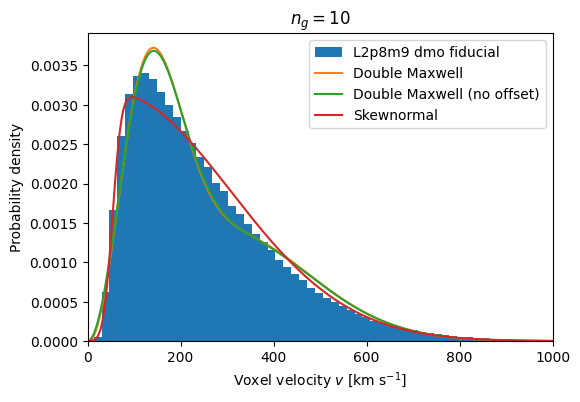

In [7]:
v_large = dmo_large.voxel_velocity[0][dmo_large.number_density == n_g]

fig, ax = plt.subplots(1,1,figsize=[6,4])

ax.hist(v_large, bins=100, density=True, label='L2p8m9 dmo fiducial')

vv = np.linspace(0, 1000, 1000)
ax.plot(vv, double_maxwell(vv, *fit_dm_large), label='Double Maxwell')
ax.plot(vv, double_maxwell_nooffset(vv, *fit_dm_nooff_large), label='Double Maxwell (no offset)')
ax.plot(vv, skewnorm.pdf(vv, *fit_sn_large), label='Skewnormal')

ax.set(
    xlabel='Voxel velocity $v$ [km s$^{-1}$]',
    ylabel='Probability density',
    xlim=[0, 1000],
    title='$n_g=10$'
)
ax.legend()
plt.show()

The zero-centered MB and translated MB distributions perform relatively similarly. They both struggle in modelling the skewness of the distribution of the velocities. The skewnorm overpredicts medium sized velocities and underpredicts low velocities.

We also observe the performance of all models in a high number density bin ($n_g = 60$).

In [8]:
n_g = 60
fit_dm_large_60 = fit_large_box(double_maxwell, dmo_small, dmo_large, n_g, [200, 100, 100, 300, .5], bounds=(*nones(4), (.1, .9)))
fit_dm_nooff_large_60 = fit_large_box(double_maxwell_nooffset, dmo_small, dmo_large, n_g, [200, 100, .5], bounds=(*nones(2), (.1, .9)))
fit_sn_large_60 = fit_large_box(skewnorm.pdf, dmo_small, dmo_large, n_g, [10, 50, 250])

/var/tmp/zegveld/ipykernel_1531290/4228528347.py:3: RuntimeWarning: divide by zero encountered in log10
  mll_small = lambda args, v=v_small: -np.sum(np.log10(pdf(v, *args)))
/data2/quinten/.venv4/lib64/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


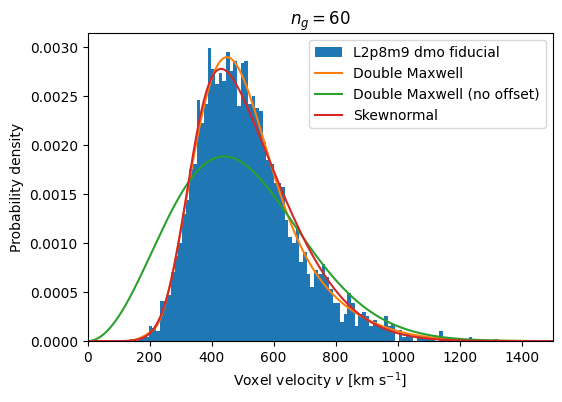

In [9]:
v_large = dmo_large.voxel_velocity[0][dmo_large.number_density == n_g]

fig, ax = plt.subplots(1,1,figsize=[6,4])

ax.hist(v_large, bins=100, density=True, label='L2p8m9 dmo fiducial')

vv = np.linspace(0, 1500, 1000)
ax.plot(vv, double_maxwell(vv, *fit_dm_large_60), label='Double Maxwell')
ax.plot(vv, double_maxwell_nooffset(vv, *fit_dm_nooff_large_60), label = 'Double Maxwell (no offset)')
ax.plot(vv, skewnorm.pdf(vv, *fit_sn_large_60), label='Skewnormal')

ax.set(
    xlabel='Voxel velocity $v$ [km s$^{-1}$]',
    ylabel='Probability density',
    xlim=[0, 1500],
    title='$n_g=60$',
)
ax.legend()

plt.show()

For this large number density, the DM with the extra x-translation parameter performs best. However, physically speaking, this is no better than using the skewnormal. The zero-centers DM performs very poorly.

Together with the low number density bin, the skewnormal distribution still performs best overall, and will remain our fiducial model.

We found the following values for our models:

In [11]:
print(f'n_g = 10\nDM: \t\t\t{fit_dm_large}\nSkewnormal: \t\t{fit_sn_large}\nDM zero-centered: \t{fit_dm_nooff_large}')
print(f'\nn_g = 60\nDM: \t\t\t{fit_dm_large_60}\nSkewnormal: \t\t{fit_sn_large_60}\nDM zero-centered: \t{fit_dm_nooff_large_60}')

n_g = 10
DM: 			[221.71304942  92.19227819   4.29480955   1.95899978   0.49985361]
Skewnormal: 		[ 16.38296492  53.66787321 253.17580878]
DM zero-centered: 	[223.50481601  93.72655156   0.5009966 ]

n_g = 60
DM: 			[286.51836328 160.35020081 121.56035069 211.93397093   0.4278831 ]
Skewnormal: 		[  3.82863209 324.81480665 248.90446877]
DM zero-centered: 	[311.57587796 311.568557     0.9       ]
